# FedResonance — when is each compression mode applied?

This notebook makes the **per-layer, per-round mode-switch rule** of
`algorithms/fed_resonance.py` *visible*: for ResNet-8 (and other models) it shows
each layer's type, matrix shape, and the compression mode FedResonance would use,
plus the SVD rank-selection that decides *how much* a layer is compressed.

**The real switch rule** (exact branch order from `client_update`):

1. `layer_type == "embedding"` → **SPARSE** (Top-k, keep `embedding_topk_ratio`)
2. `layer_type in {"norm","bias"}` → **DENSE** (full, no SVD)
3. else (conv / linear / other):
   - `numel < rank_min*2` → **DENSE**
   - `beta < 0.1` (battery critical) → **SVD_FORCED** (rank = `rank_min`)
   - else, if a stored basis explains the gradient (`proj_energy ≥ rank_coherence_thresh`) → **SUBSPACE** (send only r coefficients)
   - else → **SVD** (adaptive rank; also (re)builds the basis)

`layer_type` is decided by `_detect_layer_type` (name keywords + shape).
Error feedback carries whatever a mode drops, so no gradient info is lost.


In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))  # repo root (notebook lives in notebooks/)

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from models.registry import get_model
from algorithms.fed_resonance import (
    _detect_layer_type, _matrix_form, compress_low_rank, FedResonance,
)

# Default config keys FedResonance reads (from get_default_config()).
CFG = FedResonance().get_default_config()
RANK_MIN  = CFG["rank_min"]            # 4
RANK_MAX  = CFG["rank_max"]            # 32
EPS       = CFG["spectral_energy_thresh"]  # 0.95
TAU_RANK  = CFG["rank_coherence_thresh"]   # 0.7  (subspace gate)
print(f"rank_min={RANK_MIN}  rank_max={RANK_MAX}  spectral_energy_thresh={EPS}  rank_coherence_thresh={TAU_RANK}")


rank_min=4  rank_max=32  spectral_energy_thresh=0.95  rank_coherence_thresh=0.7


In [2]:
def static_mode(name, tensor, has_basis=False, battery_critical=False,
                rank_min=RANK_MIN):
    """Replicates the EXACT branch order of FedResonance.client_update.
    Returns (mode, reason). `has_basis`/`battery_critical` are round-dependent;
    at round 0 there is no basis and (on a charged client) no criticality."""
    lt = _detect_layer_type(name, tensor)
    numel = tensor.numel()
    if lt == "embedding":
        return "sparse", "embedding layer → Top-k"
    if lt in ("norm", "bias"):
        return "dense", f"{lt} layer → dense (SVD overhead not worth it)"
    if numel < rank_min * 2:
        return "dense", f"numel {numel} < rank_min*2 ({rank_min*2}) → dense"
    if battery_critical:
        return "svd_forced", "beta<0.1 → SVD at rank_min (max compression)"
    if has_basis:
        return "subspace?", "stored basis: SUBSPACE if proj_energy≥0.7 else SVD"
    return "svd", "no basis yet → SVD (adaptive rank, builds basis)"


In [3]:
def layer_table(model_name, dataset="cifar10"):
    m = get_model(model_name, dataset)
    rows = []
    for name, p in m.named_parameters():
        t = p.detach()
        G = _matrix_form(t)
        mode, reason = static_mode(name, t)
        rows.append(dict(
            layer=name, type=_detect_layer_type(name, t),
            shape=str(tuple(t.shape)), matrix=f"{G.shape[0]}x{G.shape[1]}",
            numel=t.numel(), mode_round0=mode, reason=reason,
        ))
    return pd.DataFrame(rows)

df8 = layer_table("resnet8")
print("ResNet-8 — round-0 modes (no basis yet):")
df8

ResNet-8 — round-0 modes (no basis yet):


,layer,type,shape,matrix,numel,mode_round0,reason
0,stem.0.weight,conv,"(16, 3, 3, 3)",16x27,432,svd,"no basis yet → SVD (adaptive rank, builds basis)"
1,stem.1.weight,other,"(16,)",16x1,16,svd,"no basis yet → SVD (adaptive rank, builds basis)"
2,stem.1.bias,bias,"(16,)",16x1,16,dense,bias layer → dense (SVD overhead not worth it)
3,layer1.conv1.weight,conv,"(16, 16, 3, 3)",16x144,2304,svd,"no basis yet → SVD (adaptive rank, builds basis)"
4,layer1.bn1.weight,norm,"(16,)",16x1,16,dense,norm layer → dense (SVD overhead not worth it)
5,layer1.bn1.bias,norm,"(16,)",16x1,16,dense,norm layer → dense (SVD overhead not worth it)
6,layer1.conv2.weight,conv,"(16, 16, 3, 3)",16x144,2304,svd,"no basis yet → SVD (adaptive rank, builds basis)"
7,layer1.bn2.weight,norm,"(16,)",16x1,16,dense,norm layer → dense (SVD overhead not worth it)
8,layer1.bn2.bias,norm,"(16,)",16x1,16,dense,norm layer → dense (SVD overhead not worth it)
9,layer2.conv1.weight,conv,"(32, 16, 3, 3)",32x144,4608,svd,"no basis yet → SVD (adaptive rank, builds basis)"


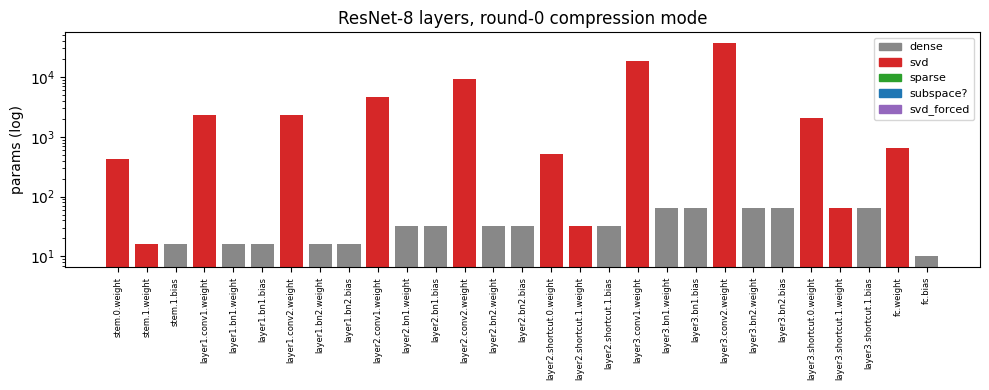

mode_round0
dense    16
svd      13
Name: count, dtype: int64


In [4]:
# How the fleet's per-round modes are distributed (round 0) — by param count.
COLORS = {"dense":"#888888","svd":"#d62728","sparse":"#2ca02c",
          "subspace?":"#1f77b4","svd_forced":"#9467bd"}
fig, ax = plt.subplots(figsize=(10,4))
xs = range(len(df8))
ax.bar(xs, df8["numel"], color=[COLORS[m] for m in df8["mode_round0"]])
ax.set_yscale("log"); ax.set_ylabel("params (log)"); ax.set_title("ResNet-8 layers, round-0 compression mode")
ax.set_xticks(list(xs)); ax.set_xticklabels(df8["layer"], rotation=90, fontsize=6)
handles = [plt.Rectangle((0,0),1,1,color=c) for c in COLORS.values()]
ax.legend(handles, COLORS.keys(), fontsize=8)
plt.tight_layout(); plt.show()

print(df8["mode_round0"].value_counts())

**Read-out (ResNet-8, round 0).** Conv/linear weights → **SVD** (no basis exists
yet, so FedResonance runs SVD and *builds* the basis). BN/bias vectors → **DENSE**
(too small to be worth an SVD). Nothing is an embedding here, so no **SPARSE**.
**SUBSPACE** only appears from round ~2+ once a stored basis explains the new
gradient well enough (`proj_energy ≥ rank_coherence_thresh`) — that is the dynamic
part, demonstrated below.


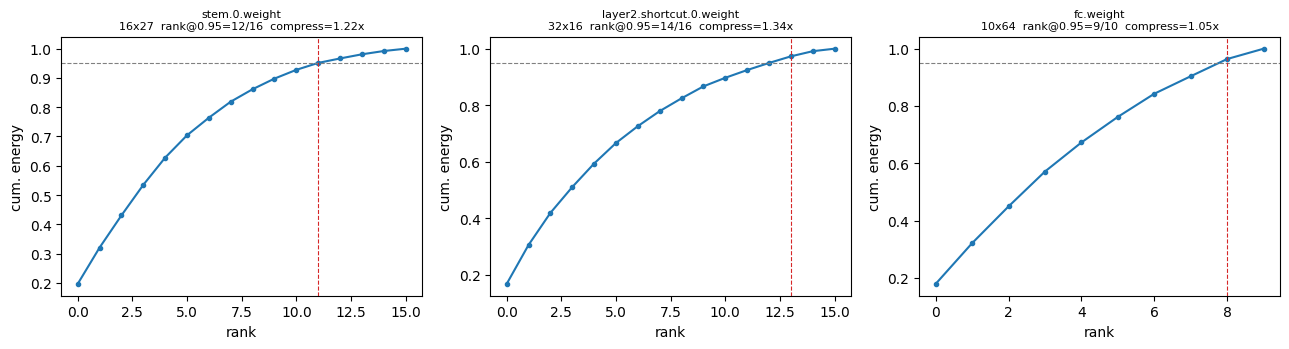

In [5]:
# HOW MUCH is a layer compressed? The adaptive rank picks the smallest r whose
# top-r singular values capture >= spectral_energy_thresh of the energy.
# We use the layer WEIGHT as a stand-in matrix to show the mechanism (real
# gradients are typically MORE low-rank, so compression in training is stronger).
m = get_model("resnet8", "cifar10")
mats = [(n, _matrix_form(p.detach())) for n, p in m.named_parameters() if p.dim() >= 2]
pick = [mats[0], mats[len(mats)//2], mats[-1]]   # shallow, mid, head

fig, axes = plt.subplots(1, len(pick), figsize=(13,3.6))
for ax, (name, G) in zip(axes, pick):
    S = torch.linalg.svdvals(G.float())
    energy = (S**2)
    cum = torch.cumsum(energy, 0) / energy.sum()
    r = int((cum >= EPS).nonzero()[0]) + 1 if (cum >= EPS).any() else len(S)
    r = max(RANK_MIN, min(RANK_MAX, r))
    m_, n_ = G.shape
    cr = (r*(m_+n_+1)) / (m_*n_)         # SVD bytes / dense bytes
    ax.plot(cum.numpy(), marker=".")
    ax.axhline(EPS, color="grey", ls="--", lw=0.8)
    ax.axvline(r-1, color="#d62728", ls="--", lw=0.8)
    ax.set_title(f"{name}\n{m_}x{n_}  rank@{EPS}={r}/{min(m_,n_)}  compress={cr:.2f}x", fontsize=8)
    ax.set_xlabel("rank"); ax.set_ylabel("cum. energy")
plt.tight_layout(); plt.show()

**Compression ratio** = SVD bytes `r·(m+n+1)` / dense bytes `m·n`. A value < 1
means the SVD transmission is cheaper than sending the dense layer; > 1 means SVD
is *not* worth it (tiny / near-full-rank layers) — which is exactly why
FedResonance keeps small layers **dense**. On freshly-initialised weights the
spectrum is near-flat (little compression); real training gradients decay faster,
so the chosen rank — and the savings — are larger in practice.


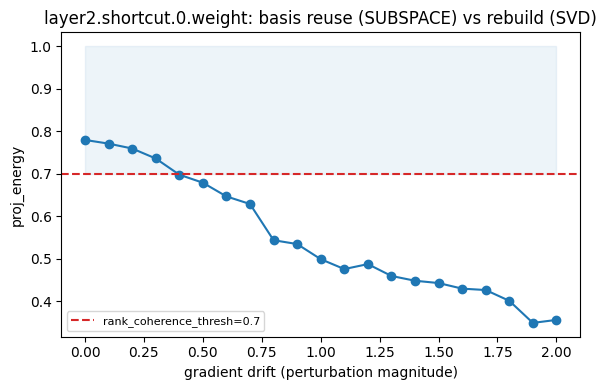

Above the line → SUBSPACE (reuse basis, send r coeffs); below → SVD (rebuild).


In [6]:
# DYNAMIC: subspace vs SVD. Build a basis B (rank r) from a layer's SVD, then
# perturb the gradient and watch proj_energy = ||B B^T G'||^2 / ||G'||^2.
# proj_energy >= rank_coherence_thresh (0.7) -> SUBSPACE (cheap); else -> SVD.
name, G0 = mats[len(mats)//2]
G0 = G0.float()
U, S, Vt = torch.linalg.svd(G0, full_matrices=False)
r = max(RANK_MIN, min(RANK_MAX, 8))
B = U[:, :r]                                    # stored basis (m x r)

eps_grid = np.linspace(0, 2.0, 21)
proj = []
torch.manual_seed(0)
for e in eps_grid:
    noise = torch.randn_like(G0); noise = noise / noise.norm() * G0.norm()
    Gp = G0 + e * noise
    pe = ((B @ (B.t() @ Gp)).pow(2).sum() / Gp.pow(2).sum()).item()
    proj.append(pe)

fig, ax = plt.subplots(figsize=(6,4))
ax.plot(eps_grid, proj, "o-")
ax.axhline(TAU_RANK, color="#d62728", ls="--", label=f"rank_coherence_thresh={TAU_RANK}")
ax.fill_between(eps_grid, TAU_RANK, 1.0, alpha=0.08, color="#1f77b4")
ax.set_xlabel("gradient drift (perturbation magnitude)"); ax.set_ylabel("proj_energy")
ax.set_title(f"{name}: basis reuse (SUBSPACE) vs rebuild (SVD)")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()
print("Above the line → SUBSPACE (reuse basis, send r coeffs); below → SVD (rebuild).")

## The four parameters you asked about

| param | role (in the real code) | ↑ raises it ⇒ | speed / energy | convergence |
|---|---|---|---|---|
| **`rank_coherence_thresh`** (`tau_rank`, 0.7) | min `proj_energy` for **SUBSPACE** vs SVD (line ~1074) | stricter → more **SVD** | more comm+compute, more accurate gradient | slightly faster per useful round; lower → more subspace reuse (cheaper, EF covers staleness) |
| **`rsvd_oversample`** (`p`, 10) | extra random columns for randomized SVD accuracy | more accurate rSVD | a bit slower / more memory | negligible |
| **`rsvd_power_iter`** (`q`, 2) | power iterations for rSVD on slow-decaying spectra | more accurate rSVD | slower | negligible |
| **`subspace_drift_thresh`** (`tau_drift`, 0.1) | *intended* basis-staleness gate | — | — | — |

**Honesty note (read from the code):** `subspace_drift_thresh` is currently
**read but not used** — `subspace_drift()` is never called in `client_update`; the
basis-staleness decision is made entirely by `proj_energy ≥ rank_coherence_thresh`.
So changing `subspace_drift_thresh` has **no effect** today. The docstring still
lists it as part of the rule; the code does not implement that gate.

**With `svd_fast=True` (default):** ResNet-8 layers are small (`min(m,n) ≤ 256`),
so they take the **full-SVD** path — `rsvd_oversample`/`rsvd_power_iter` then only
matter for *large* matrices (the randomized path). They do **not** change which
mode is chosen, only the SVD numerics.


/Users/joshuajusteyunpeinikiema/Documents/PhD_UM6P/Stat_of_art_EnergyEfficientFL/fedlab_zmq/models/registry.py:304: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=depth)


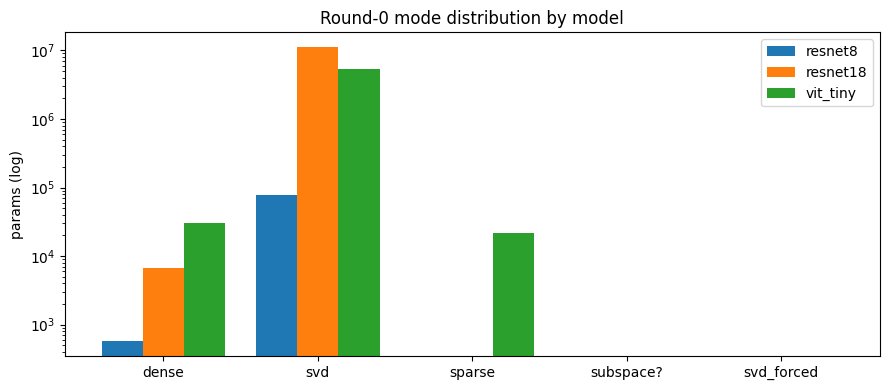

In [7]:
# Mode distribution across architectures (round 0), by parameter count.
fig, ax = plt.subplots(figsize=(9,4))
models = ["resnet8", "resnet18", "vit_tiny"]
allmodes = ["dense","svd","sparse","subspace?","svd_forced"]
width = 0.8/len(models)
for i, mn in enumerate(models):
    try:
        d = layer_table(mn)
    except Exception as ex:
        print(f"skip {mn}: {ex}"); continue
    by = d.groupby("mode_round0")["numel"].sum()
    vals = [by.get(mm, 0) for mm in allmodes]
    ax.bar([x + i*width for x in range(len(allmodes))], vals, width, label=mn)
ax.set_yscale("log"); ax.set_ylabel("params (log)")
ax.set_xticks([x + width for x in range(len(allmodes))]); ax.set_xticklabels(allmodes)
ax.set_title("Round-0 mode distribution by model"); ax.legend()
plt.tight_layout(); plt.show()